In [2]:
import pandas as pd        
import numpy as np         
import matplotlib.pyplot as plt   
import seaborn as sns     

In [3]:
# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)  
plt.rcParams['font.size'] = 12             
sns.set_style("whitegrid")                
sns.set_palette("Reds_r")                 

In [4]:
tb_data = pd.read_csv('kncv_nigeria_tb_data_cleaned.csv')
tb_data.head()


,patient_id,state,LGA,sex,age,screening_date,case_finding_method,referred_by,presumptive_tb,is_plhiv,...,treatment_start_date,treatment_regimen,dots_method,treatment_facility_level,treatment_outcome,outcome_date,lost_to_followup_reason,tpt_eligible,tpt_initiated,treatment_duration_months
0,KNCV-008962,Katsina,Katsina Central LGA,Female,27.0,2022-05-03,Facility-Based,PLHIV Clinic,Yes,No,...,2022-05-17,Shorter DR-TB Regimen,Facility DOTS,Primary,Treatment Success,2024-03-05,NaN,NaN,NaN,21.9
1,KNCV-027061,Lagos,Mushin,Male,15.0,2024-01-13,Facility-Based,Self Referral,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,NaN
2,KNCV-059804,Osun,Osun Central LGA,Male,37.0,2022-12-24,Index Testing,PLHIV Clinic,Yes,No,...,2023-01-03,2HRZE/4HR,Facility DOTS,Primary,Treatment Success,2023-06-28,NaN,NaN,NaN,5.9
3,KNCV-010661,Imo,Imo Central LGA,Female,51.0,2021-10-23,Digital X-ray,Contact Tracing,Yes,No,...,2021-10-27,2HRZE/4HR,Facility DOTS,Secondary,Died,2022-05-03,NaN,NaN,NaN,6.3
4,KNCV-003639,Anambra,Anambra Central LGA,Male,48.0,2023-05-29,Community Screening,Health Worker,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,NaN


In [5]:
# Parse dates
date_cols = ['screening_date', 'diagnosis_date', 'treatment_start_date', 'outcome_date']
for col in date_cols:
    tb_data[col] = pd.to_datetime(tb_data[col], errors='coerce')

print("Shape:", tb_data.shape)
print("Date range:", tb_data['screening_date'].min(), "to", tb_data['screening_date'].max())

Shape: (60000, 27)
Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00


C:\Users\USER\AppData\Local\Temp\ipykernel_14604\804875809.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_counts, x='patient_count', y='state', palette='Reds_r')


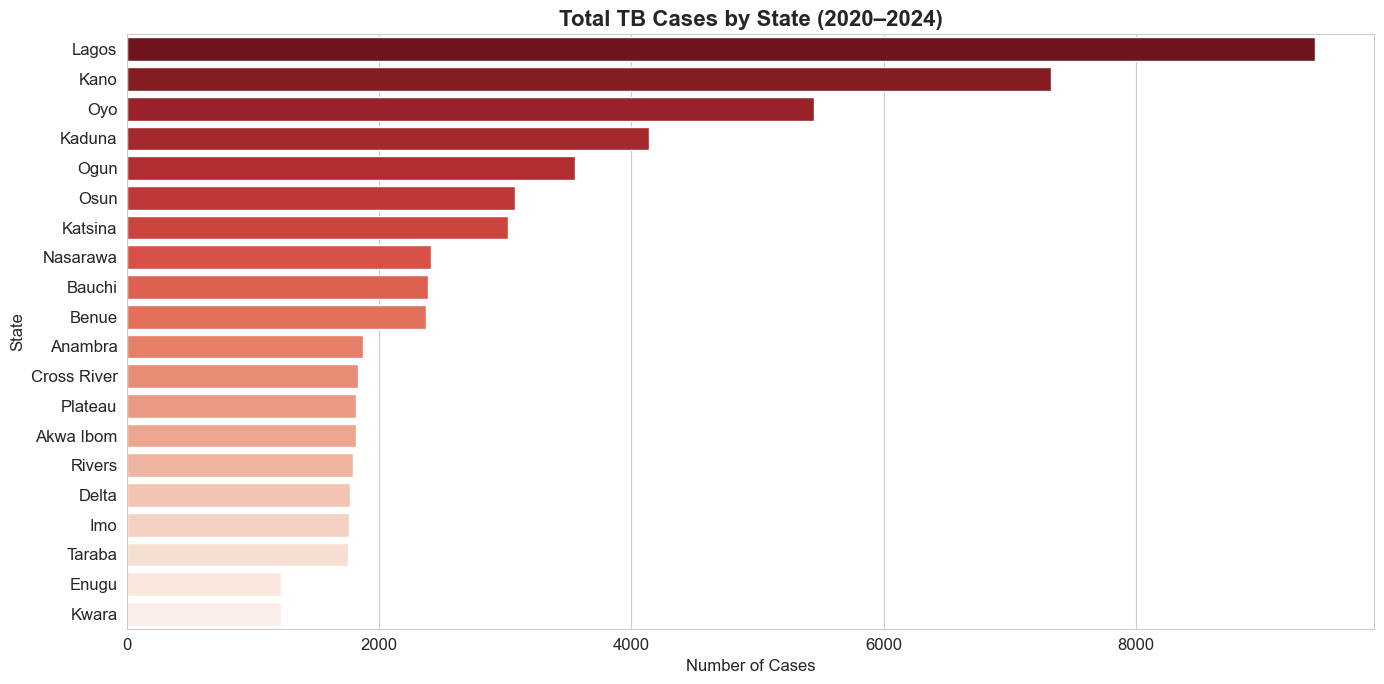

In [6]:
#── QUESTION 1: WHERE ARE PATIENTS BEING FOUND? ──────────────────
# Count patients by state
state_counts = tb_data['state'].value_counts().reset_index()
state_counts.columns = ['state', 'patient_count']

plt.figure(figsize=(14, 7))
sns.barplot(data=state_counts, x='patient_count', y='state', palette='Reds_r')
plt.title('Total TB Cases by State (2020–2024)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Cases')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Insight 1: Geographic Distribution of TB Cases

Lagos recorded the highest number of TB cases (2020–2024), followed by Kano and Oyo — consistent with Nigeria's known high-burden states. The North-West and South-West zones dominate case notifications, while Kwara recorded the least cases. This pattern reflects both population density and the strength of case finding activities in these states.

C:\Users\USER\AppData\Local\Temp\ipykernel_14604\1526262108.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=method_counts, x='method', y='count', palette='Reds_r')


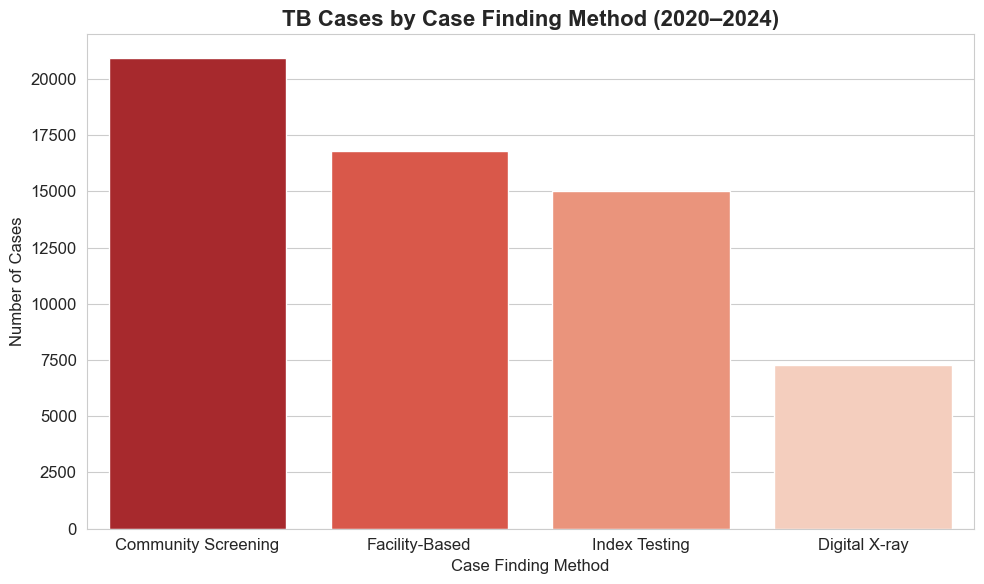

In [7]:
# Case finding method distribution
method_counts = tb_data['case_finding_method'].value_counts().reset_index()
method_counts.columns = ['method', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=method_counts, x='method', y='count', palette='Reds_r')
plt.title('TB Cases by Case Finding Method (2020–2024)', fontsize=16, fontweight='bold')
plt.xlabel('Case Finding Method')
plt.ylabel('Number of Cases')
plt.tight_layout()
plt.show()

## Insight 2: Case Finding Methods

Community Screening accounts for the highest proportion of TB case notifications, followed by Facility-Based detection and Index Testing. Digital X-ray contributes the least, likely reflecting limited availability of portable digital X-ray machines across program states. This suggests that community-level interventions remain the backbone of KNCV's case finding strategy, while scale-up of digital X-ray technology could unlock more undetected cases.

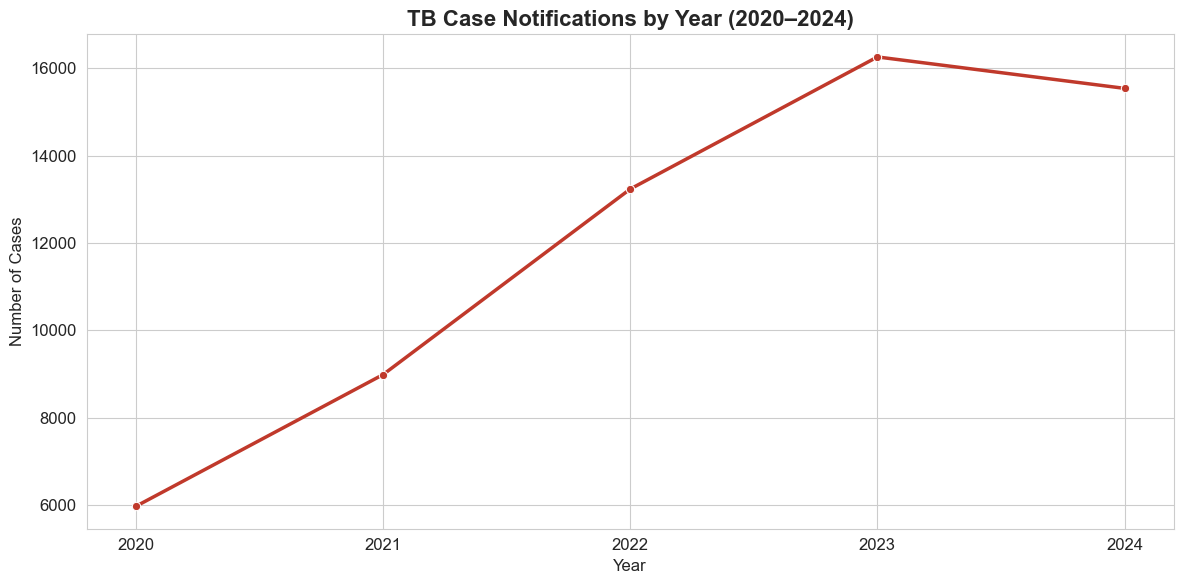

In [8]:
# COVID impact on case finding over time
tb_data['year'] = tb_data['screening_date'].dt.year

yearly_cases = tb_data.groupby('year').size().reset_index()
yearly_cases.columns = ['year', 'count']

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_cases, x='year', y='count', marker='o', linewidth=2.5, color='#C0392B')
plt.title('TB Case Notifications by Year (2020–2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.xticks([2020, 2021, 2022, 2023, 2024])
plt.tight_layout()
plt.show()

## Insight 3: COVID-19 Impact on TB Case Finding

TB case notifications dropped significantly in 2020, reflecting the disruption of TB services during the COVID-19 pandemic. Health workers were redeployed, community screening was suspended, and patients avoided health facilities. Recovery began in 2021 and accelerated through 2022–2024, with case notifications reaching their peak by 2023. This trend mirrors global reports of COVID-19's devastating impact on TB programs and highlights the importance of resilient health systems that can maintain essential services during emergencies.

In [9]:
#── QUESTION 2: HOW LONG DOES THE PATIENT JOURNEY TAKE? ──────────

#Calculate time intervals (only for confirmed TB patients)
confirmed = tb_data[tb_data['tb_type'].notna()].copy()

#Days from screening to diagnosis
confirmed['days_to_diagnosis'] = (
    confirmed['diagnosis_date'] - confirmed['screening_date']
).dt.days

# Days from diagnosis to treatment start
confirmed['days_to_treatment'] = (
    confirmed['treatment_start_date'] - confirmed['diagnosis_date']
).dt.days

print("Average days screening → diagnosis:", confirmed['days_to_diagnosis'].mean().round(1))
print("Average days diagnosis → treatment:", confirmed['days_to_treatment'].mean().round(1))
print("Average total days screening → treatment:", 
      (confirmed['days_to_diagnosis'] + confirmed['days_to_treatment']).mean().round(1))

Average days screening → diagnosis: 7.5
Average days diagnosis → treatment: 4.5
Average total days screening → treatment: 12.0


C:\Users\USER\AppData\Local\Temp\ipykernel_14604\558913592.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=journey_data, x='Stage', y='Average Days', palette='Reds_r')


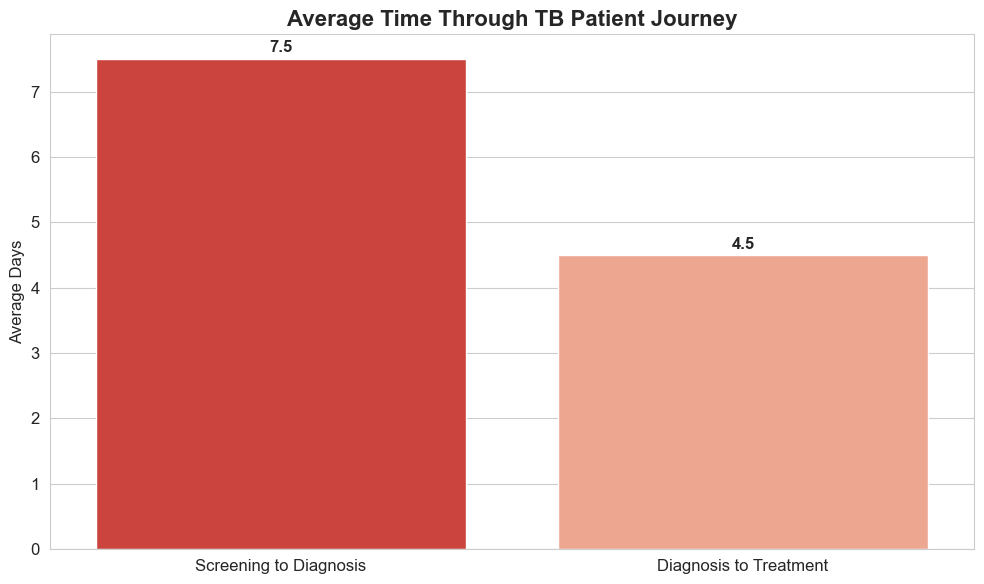

In [10]:
# Visualize the patient journey timeline
journey_data = pd.DataFrame({
    'Stage': ['Screening to Diagnosis', 'Diagnosis to Treatment'],
    'Average Days': [
        confirmed['days_to_diagnosis'].mean().round(1),
        confirmed['days_to_treatment'].mean().round(1)
    ]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=journey_data, x='Stage', y='Average Days', palette='Reds_r')
plt.title('Average Time Through TB Patient Journey', fontsize=16, fontweight='bold')
plt.xlabel('')
plt.ylabel('Average Days')
for i, v in enumerate(journey_data['Average Days']):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Insight 4: Patient Journey Timeline

On average, it takes 7.5 days from screening to TB diagnosis and a further 4.5 days from diagnosis to treatment initiation — a total of approximately 12 days from first contact to treatment start. While this is within acceptable program targets, reducing the screening-to-diagnosis gap remains critical, particularly in high-burden states where diagnostic capacity may be strained. Faster diagnosis directly reduces transmission risk in communities.

C:\Users\USER\AppData\Local\Temp\ipykernel_14604\2735720973.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outcome_counts, x='outcome', y='count', palette='Reds_r')


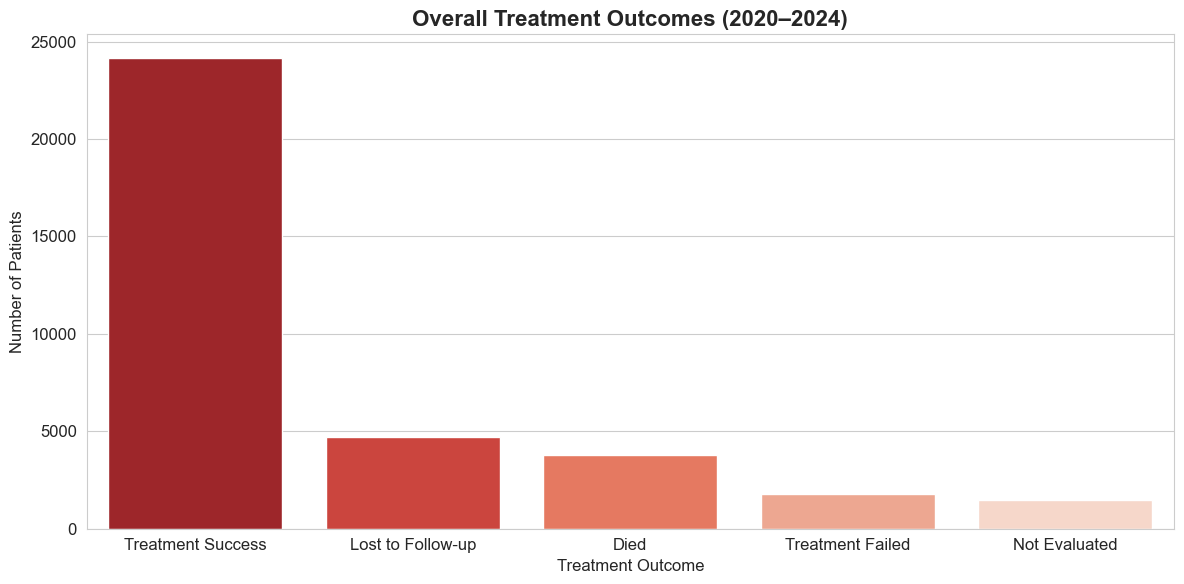

In [11]:
# ── QUESTION 3: WHO HAS THE WORST OUTCOMES? ──────────────────────

# Overall treatment outcomes
outcome_counts = tb_data['treatment_outcome'].value_counts().reset_index()
outcome_counts.columns = ['outcome', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(data=outcome_counts, x='outcome', y='count', palette='Reds_r')
plt.title('Overall Treatment Outcomes (2020–2024)', fontsize=16, fontweight='bold')
plt.xlabel('Treatment Outcome')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

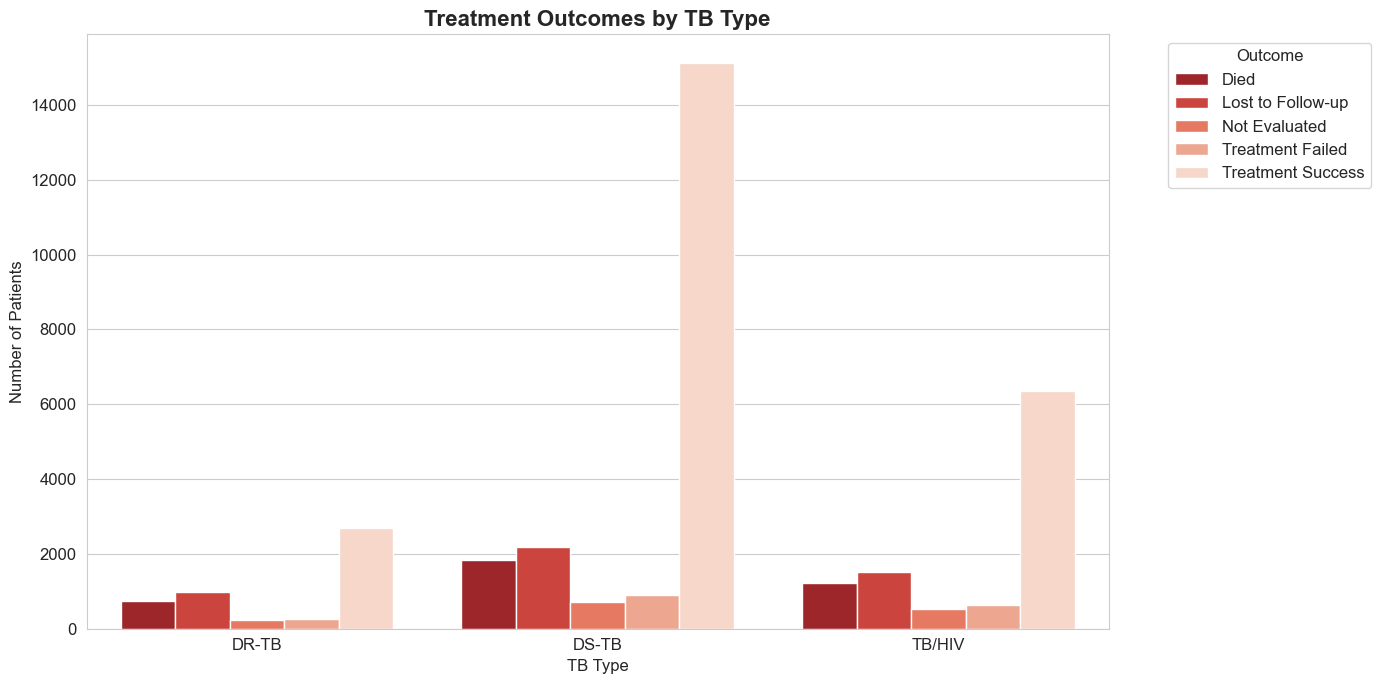

In [12]:
# Outcomes by TB type
outcome_by_tb = tb_data.groupby(['tb_type', 'treatment_outcome']).size().reset_index()
outcome_by_tb.columns = ['tb_type', 'treatment_outcome', 'count']

plt.figure(figsize=(14, 7))
sns.barplot(data=outcome_by_tb, x='tb_type', y='count', hue='treatment_outcome', palette='Reds_r')
plt.title('Treatment Outcomes by TB Type', fontsize=16, fontweight='bold')
plt.xlabel('TB Type')
plt.ylabel('Number of Patients')
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Insight 5: Treatment Outcomes by TB Type

Treatment Success rates are highest among DS-TB patients, reflecting the effectiveness of the standard 6-month regimen. DR-TB patients show significantly worse outcomes; higher rates of death, loss to follow-up, and treatment failure — consistent with the challenges of drug-resistant disease including longer treatment duration (18-24 months), more toxic drug regimens, and higher pill burden which contributes to patient dropout. TB/HIV co-infected patients also show poorer outcomes compared to DS-TB, highlighting the compounding effect of dual infection on treatment success.

C:\Users\USER\AppData\Local\Temp\ipykernel_14604\419136336.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=success_rate, x='success_rate', y='state', palette='Reds_r')


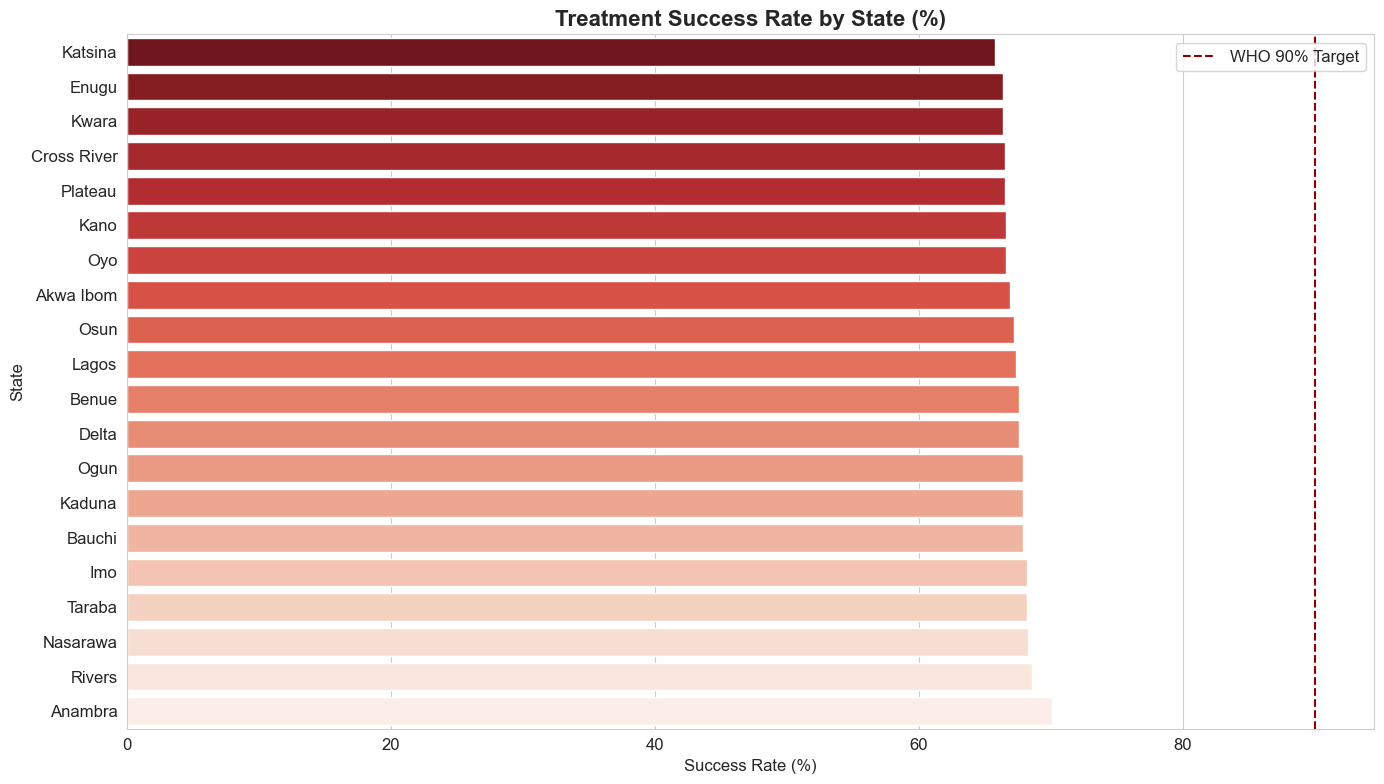

In [13]:
# Treatment success RATE by state
state_outcomes = tb_data[tb_data['treatment_outcome'].notna()].groupby(
    ['state', 'treatment_outcome']
).size().reset_index()
state_outcomes.columns = ['state', 'treatment_outcome', 'count']

# Calculate success rate per state
total_by_state = state_outcomes.groupby('state')['count'].sum().reset_index()
total_by_state.columns = ['state', 'total']

success_by_state = state_outcomes[state_outcomes['treatment_outcome'] == 'Treatment Success']
success_rate = success_by_state.merge(total_by_state, on='state')
success_rate['success_rate'] = (success_rate['count'] / success_rate['total'] * 100).round(1)
success_rate = success_rate.sort_values('success_rate')

plt.figure(figsize=(14, 8))
sns.barplot(data=success_rate, x='success_rate', y='state', palette='Reds_r')
plt.title('Treatment Success Rate by State (%)', fontsize=16, fontweight='bold')
plt.xlabel('Success Rate (%)')
plt.ylabel('State')
plt.axvline(x=90, color='darkred', linestyle='--', label='WHO 90% Target')
plt.legend()
plt.tight_layout()
plt.show()

## Insight 6: Treatment Success Rate by State

No state in the program areas met the WHO 90% treatment success rate target. Success rates vary across states, reflecting differences in health system capacity, patient adherence support, and drug availability. States with lower success rates should be prioritized for targeted interventions such as enhanced DOTS support, community follow-up, and patient education. Closing this gap is critical to Nigeria's progress toward the End TB targets by 2030.

C:\Users\USER\AppData\Local\Temp\ipykernel_14604\835698797.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_plhiv, x='is_plhiv', y='success_rate', palette='Reds_r')


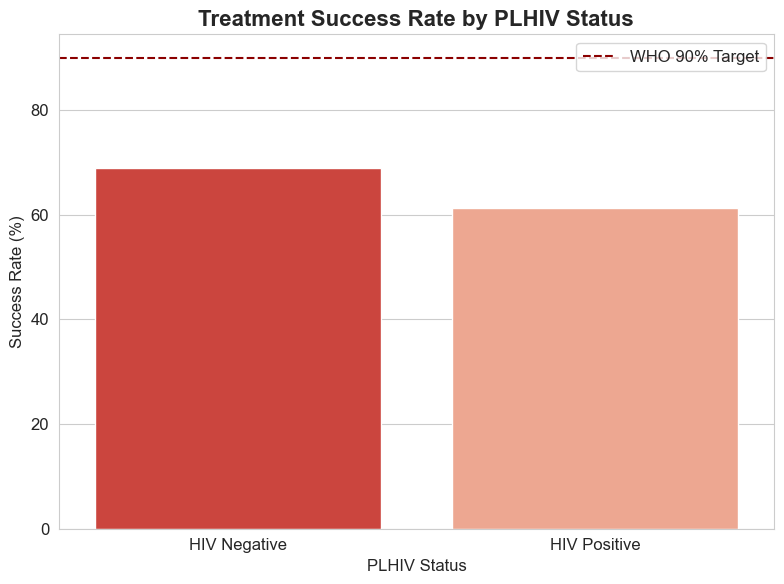

In [14]:
# Outcomes by PLHIV status
plhiv_outcomes = tb_data[tb_data['treatment_outcome'].notna()].groupby(
    ['is_plhiv', 'treatment_outcome']
).size().reset_index()
plhiv_outcomes.columns = ['is_plhiv', 'treatment_outcome', 'count']

# Calculate success rate
total_plhiv = plhiv_outcomes.groupby('is_plhiv')['count'].sum().reset_index()
total_plhiv.columns = ['is_plhiv', 'total']

success_plhiv = plhiv_outcomes[plhiv_outcomes['treatment_outcome'] == 'Treatment Success']
rate_plhiv = success_plhiv.merge(total_plhiv, on='is_plhiv')
rate_plhiv['success_rate'] = (rate_plhiv['count'] / rate_plhiv['total'] * 100).round(1)

plt.figure(figsize=(8, 6))
sns.barplot(data=rate_plhiv, x='is_plhiv', y='success_rate', palette='Reds_r')
plt.title('Treatment Success Rate by PLHIV Status', fontsize=16, fontweight='bold')
plt.xlabel('PLHIV Status')
plt.ylabel('Success Rate (%)')
plt.xticks([0, 1], ['HIV Negative', 'HIV Positive'])
plt.axhline(y=90, color='darkred', linestyle='--', label='WHO 90% Target')
plt.legend()
plt.tight_layout()
plt.show()

## Insight 7: Treatment Outcomes by PLHIV Status

HIV-negative TB patients show significantly higher treatment success rates compared to PLHIV. This reflects the compounding burden of dual infection — HIV weakens the immune system, increases pill burden through concurrent ART, and raises the risk of drug interactions and side effects. These findings underscore the importance of integrated TB/HIV services, ensuring PLHIV on TB treatment receive enhanced adherence support and close clinical monitoring.

C:\Users\USER\AppData\Local\Temp\ipykernel_14604\3691839588.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ltfu_counts, x='count', y='reason', palette='Reds_r')


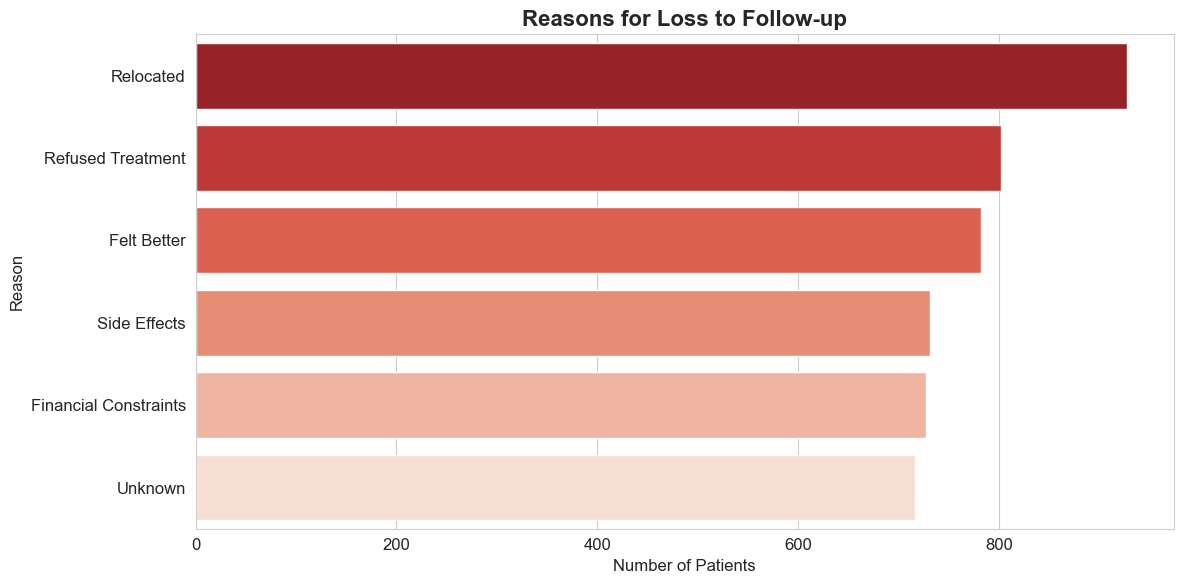

In [15]:
# Lost to Follow-up reasons
ltfu_data = tb_data[tb_data['lost_to_followup_reason'].notna()]
ltfu_counts = ltfu_data['lost_to_followup_reason'].value_counts().reset_index()
ltfu_counts.columns = ['reason', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(data=ltfu_counts, x='count', y='reason', palette='Reds_r')
plt.title('Reasons for Loss to Follow-up', fontsize=16, fontweight='bold')
plt.xlabel('Number of Patients')
plt.ylabel('Reason')
plt.tight_layout()
plt.show()

## Insight 8: Reasons for Loss to Follow-up

Relocation is the leading reason for loss to follow-up among TB patients, reflecting Nigeria's high rates of internal migration. Patients who move during treatment often fail to re-enroll at facilities in their new location. Financial constraints and feeling better also contribute significantly — the latter being particularly concerning as patients who stop treatment prematurely due to symptom improvement risk developing drug resistance. These findings highlight the need for robust patient tracking systems and community-based follow-up mechanisms.

C:\Users\USER\AppData\Local\Temp\ipykernel_14604\3632206267.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tpt_counts, x='eligible', y='count', palette='Reds_r', ax=axes[0])
C:\Users\USER\AppData\Local\Temp\ipykernel_14604\3632206267.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tpt_initiated, x='initiated', y='count', palette='Reds_r', ax=axes[1])


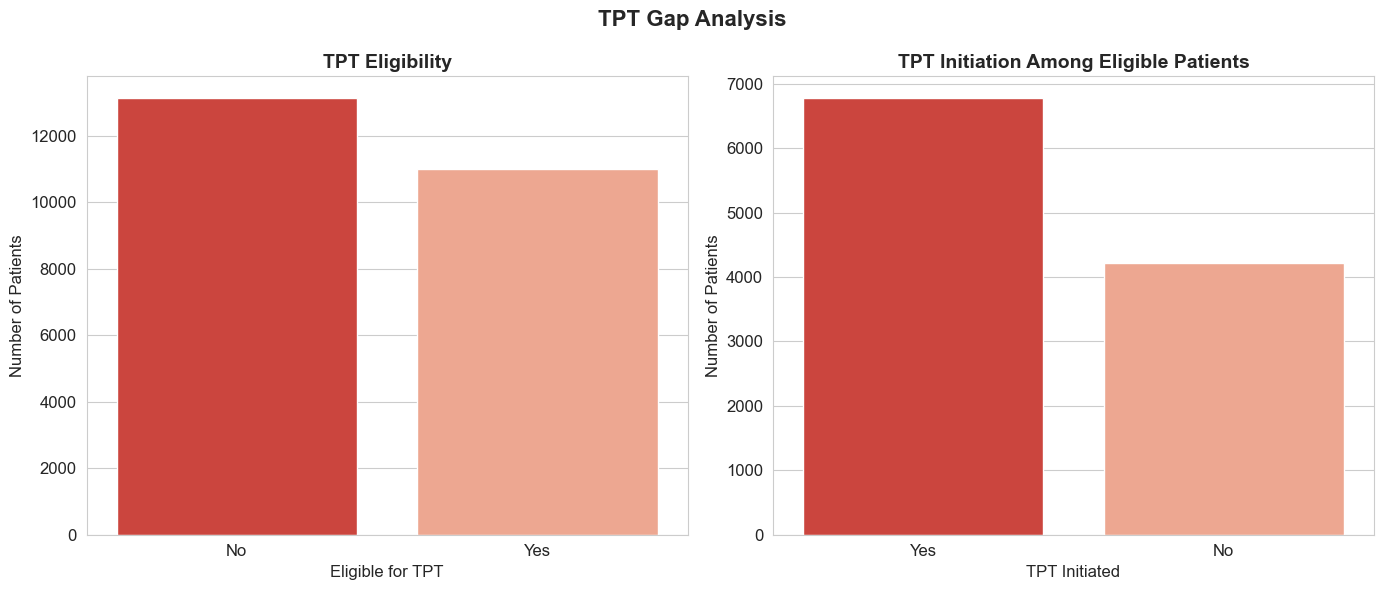

In [16]:
# ── TPT GAP ANALYSIS ──────────────────────────────────────────────

# Only look at TPT eligible patients (non-confirmed TB)
tpt_data = tb_data[tb_data['tpt_eligible'].notna()]

tpt_counts = tpt_data['tpt_eligible'].value_counts().reset_index()
tpt_counts.columns = ['eligible', 'count']

# Of those eligible, how many initiated?
tpt_eligible = tpt_data[tpt_data['tpt_eligible'] == 'Yes']
tpt_initiated = tpt_eligible['tpt_initiated'].value_counts().reset_index()
tpt_initiated.columns = ['initiated', 'count']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Eligible vs Not Eligible
sns.barplot(data=tpt_counts, x='eligible', y='count', palette='Reds_r', ax=axes[0])
axes[0].set_title('TPT Eligibility', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eligible for TPT')
axes[0].set_ylabel('Number of Patients')

# Chart 2 — Initiated vs Not Initiated (among eligible)
sns.barplot(data=tpt_initiated, x='initiated', y='count', palette='Reds_r', ax=axes[1])
axes[1].set_title('TPT Initiation Among Eligible Patients', fontsize=14, fontweight='bold')
axes[1].set_xlabel('TPT Initiated')
axes[1].set_ylabel('Number of Patients')

plt.suptitle('TPT Gap Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Insight 9: TPT Gap Analysis

Among patients eligible for Tuberculosis Preventive Therapy (TPT) — primarily PLHIV and contacts of TB patients — approximately 62% initiated TPT while 38% did not. This gap represents a significant missed opportunity for TB prevention. Eligible patients who do not initiate TPT remain at high risk of developing active TB disease. Strengthening TPT uptake through improved counseling, community follow-up, and integration with HIV services is critical to closing this prevention gap.